# Best Model — RoBERTa-base with Data Augmentation (Two-Phase)

## Phase 1 — Train + eval → `dev.txt`
- Training data: official train split + `augmented_train_data.csv`
- Evaluated on official dev split; best checkpoint saved by macro-F1
- Produces `dev.txt` (2094 lines)

## Phase 2 — Full retrain → `test.txt`
- Training data: train + aug_train + **dev + aug_dev** (no held-out set)
- Fresh `roberta-base` trained for the same number of epochs
- Produces `test.txt` (3832 lines)

**Model**: `roberta-base` · **Optimiser**: AdamW (cosine + 10% warmup) · **Loss**: class-weighted CE

In [1]:
!pip install contractions python-dotenv huggingface_hub

In [2]:
import os
import re
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
import seaborn as sns
import contractions

from dotenv import load_dotenv
from huggingface_hub import login

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    set_seed,
)

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

/home/wowthecoder/imperial-nlp-cw/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [3]:
load_dotenv()
hf_token = os.getenv('HF_TOKEN')
if hf_token:
    login(token=hf_token)
    print('HF token loaded.')
else:
    print('HF_TOKEN not found; proceeding without login.')

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HF token loaded.


In [4]:
# ============================================================
# Configuration
# ============================================================
MODEL_NAME  = 'roberta-base'
MAX_LENGTH  = 256
NUM_EPOCHS  = 5

# Notebook lives in BestModel/; data files are one level up
DATA_ROOT      = '..'
TSV_PATH       = os.path.join(DATA_ROOT, 'dontpatronizeme_pcl.tsv')
TRAIN_IDS_PATH = os.path.join(DATA_ROOT, 'train', 'train_semeval_parids-labels.csv')
DEV_IDS_PATH   = os.path.join(DATA_ROOT, 'train', 'dev_semeval_parids-labels.csv')
TEST_PATH      = os.path.join(DATA_ROOT, 'test', 'task4_test.tsv')
AUG_TRAIN_PATH = os.path.join(DATA_ROOT, 'data_augmentation', 'augmented_train_data.csv')
AUG_DEV_PATH   = os.path.join(DATA_ROOT, 'data_augmentation', 'augmented_dev_data.csv')

# Phase 1 checkpoint dir (train split only)
RUN_NAME_P1 = 'checkpoints/phase1'
# Phase 2 checkpoint dir (full data)
RUN_NAME_P2 = 'checkpoints/phase2'

DEV_TXT_PATH  = 'dev.txt'
TEST_TXT_PATH = 'test.txt'

os.makedirs(RUN_NAME_P1, exist_ok=True)
os.makedirs(RUN_NAME_P2, exist_ok=True)
print('Checkpoint dirs created.')

Checkpoint dirs created.


In [5]:
# ============================================================
# Helper functions
# ============================================================
def load_task1(tsv_path: str) -> pd.DataFrame:
    """Load labelled PCL dataset; binarise labels (0/1 -> 0, 2/3/4 -> 1)."""
    rows = []
    with open(tsv_path, encoding='utf-8') as f:
        for line in f.readlines()[4:]:
            parts = line.rstrip('\n').split('\t')
            if len(parts) < 6:
                continue
            orig_label = parts[-1]
            rows.append({
                'par_id':  str(parts[0]),
                'art_id':  parts[1],
                'keyword': parts[2],
                'country': parts[3],
                'text':    parts[4],
                'label':   0 if orig_label in {'0', '1'} else 1,
            })
    return pd.DataFrame(rows)


def load_test_tsv(test_path: str) -> pd.DataFrame:
    """Load unlabelled test set (tab-separated, no header)."""
    rows = []
    with open(test_path, encoding='utf-8') as f:
        for line in f:
            parts = line.rstrip('\n').split('\t')
            if len(parts) < 5:
                continue
            rows.append({
                'par_id':  parts[0],
                'art_id':  parts[1],
                'keyword': parts[2],
                'country': parts[3],
                'text':    parts[4],
            })
    return pd.DataFrame(rows)


def load_aug_csv(path: str) -> pd.DataFrame:
    """Load an augmented data CSV, drop stray header rows, cast label to int."""
    aug = pd.read_csv(path, dtype={'par_id': str})
    aug = aug[aug['label'].astype(str) != 'label'].copy()
    aug['label'] = aug['label'].astype(int)
    if 'clean_text' in aug.columns:
        aug['clean_text'] = aug['clean_text'].fillna(aug['text'].apply(preprocess_text))
    else:
        aug['clean_text'] = aug['text'].apply(preprocess_text)
    aug['model_text'] = make_model_text(aug)
    return aug[['par_id', 'keyword', 'country', 'text', 'clean_text', 'model_text', 'label']]


def preprocess_text(text: str) -> str:
    text = str(text)
    text = contractions.fix(text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def make_model_text(frame: pd.DataFrame) -> pd.Series:
    kw  = frame['keyword'].fillna('').astype(str).str.strip()
    cc  = frame['country'].fillna('').astype(str).str.strip()
    txt = frame['clean_text'].fillna('').astype(str).str.strip()
    return kw + ' </s> ' + cc + ' </s> ' + txt

In [6]:
# ============================================================
# Load labelled dataset + preprocess
# ============================================================
df = load_task1(TSV_PATH)
df['clean_text'] = df['text'].apply(preprocess_text)
df['model_text'] = make_model_text(df)

print(f'Full labelled dataset: {len(df):,} rows')
print(df['label'].value_counts().rename({0: 'No-PCL', 1: 'PCL'}))

Full labelled dataset: 10,469 rows
label
No-PCL    9476
PCL        993
Name: count, dtype: int64


In [7]:
# ============================================================
# Official train / dev split
# ============================================================
train_ids_df = pd.read_csv(TRAIN_IDS_PATH, dtype={'par_id': str})
dev_ids_df   = pd.read_csv(DEV_IDS_PATH,   dtype={'par_id': str})

train_par_ids = set(train_ids_df['par_id'].astype(str))
dev_par_ids   = set(dev_ids_df['par_id'].astype(str))

train_base_df = df[df['par_id'].isin(train_par_ids)].copy().reset_index(drop=True)

# Dev set ordered exactly as the official split file (required for correct dev.txt)
dev_base_df = (
    dev_ids_df[['par_id']]
    .merge(df[df['par_id'].isin(dev_par_ids)], on='par_id', how='left')
    .reset_index(drop=True)
)

# Leftover samples not in either split go to train
leftover = df[~df['par_id'].isin(train_par_ids | dev_par_ids)]
if len(leftover):
    train_base_df = pd.concat([train_base_df, leftover], ignore_index=True)
    print(f'Appended {len(leftover):,} leftover samples to train.')

print(f'Train base: {len(train_base_df):,} | PCL={int((train_base_df.label==1).sum()):,} | No-PCL={int((train_base_df.label==0).sum()):,}')
print(f'Dev base:   {len(dev_base_df):,}  | PCL={int((dev_base_df.label==1).sum()):,}  | No-PCL={int((dev_base_df.label==0).sum()):,}')

Train base: 8,375 | PCL=794 | No-PCL=7,581
Dev base:   2,094  | PCL=199  | No-PCL=1,895


In [8]:
# ============================================================
# Load augmented data
# ============================================================
aug_train_df = load_aug_csv(AUG_TRAIN_PATH)
aug_dev_df   = load_aug_csv(AUG_DEV_PATH)

print(f'aug_train : {len(aug_train_df):,} rows | PCL={int((aug_train_df.label==1).sum()):,}')
print(f'aug_dev   : {len(aug_dev_df):,} rows  | PCL={int((aug_dev_df.label==1).sum()):,}')

aug_train : 5,558 rows | PCL=5,558
aug_dev   : 995 rows  | PCL=995


In [9]:
# ============================================================
# Tokenisation helpers
# ============================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)


def build_dataset(frame: pd.DataFrame, has_labels: bool = True) -> Dataset:
    cols = ['model_text', 'label'] if has_labels else ['model_text']
    ds = (
        Dataset.from_pandas(
            frame[cols].rename(columns={'model_text': 'text'}),
            preserve_index=False,
        )
        .map(tokenize, batched=True, remove_columns=['text'])
    )
    if has_labels:
        ds = ds.rename_column('label', 'labels')
        ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
    else:
        ds.set_format(type='torch', columns=['input_ids', 'attention_mask'])
    return ds

In [10]:
# ============================================================
# Evaluation metrics (macro-F1 focused)
# ============================================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "f1_pcl": f1_score(labels, preds, average="binary", pos_label=1, zero_division=0),
        "precision_pcl": precision_score(labels, preds, average="binary", pos_label=1, zero_division=0),
        "recall_pcl": recall_score(labels, preds, average="binary", pos_label=1, zero_division=0),
    }

In [11]:
# ============================================================
# Custom Trainer with class-weighted CrossEntropyLoss
# ============================================================
class WeightedCETrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = (
            torch.tensor(class_weights, dtype=torch.float)
            if class_weights is not None else None
        )

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.logits
        weight  = self.class_weights.to(logits.device) if self.class_weights is not None else None
        loss    = nn.CrossEntropyLoss(weight=weight)(logits, labels)
        return (loss, outputs) if return_outputs else loss

---
## Phase 1 — Train on train split + augmented train data
Trains with dev as validation set; best checkpoint (by macro-F1) is restored at end.

In [12]:
# ============================================================
# Phase 1 training set: train_base + aug_train
# ============================================================
p1_train_df = pd.concat([train_base_df, aug_train_df], ignore_index=True)
p1_train_df = p1_train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

p1_cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=p1_train_df['label'].values)

print(f'Phase 1 train: {len(p1_train_df):,} | PCL={int((p1_train_df.label==1).sum()):,} | No-PCL={int((p1_train_df.label==0).sum()):,}')
print(f'Class weights -> No-PCL: {p1_cw[0]:.4f},  PCL: {p1_cw[1]:.4f}')

p1_train_ds = build_dataset(p1_train_df)
p1_dev_ds   = build_dataset(dev_base_df)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(p1_train_ds)
print(p1_dev_ds)

Phase 1 train: 13,933 | PCL=6,352 | No-PCL=7,581
Class weights -> No-PCL: 0.9189,  PCL: 1.0967


Map: 100%|██████████| 2094/2094 [00:00<00:00, 29718.35 examples/s]

Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 13933
})
Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 2094
})


In [13]:
# ============================================================
# Phase 1 model + trainer
# ============================================================
p1_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

p1_args = TrainingArguments(
    output_dir=RUN_NAME_P1,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=1e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type='cosine',
    optim='adamw_torch',
    eval_strategy='epoch',
    save_strategy='epoch',
    metric_for_best_model="f1_pcl",
    greater_is_better=True,
    load_best_model_at_end=True,
    save_total_limit=2,
    report_to='none',
    seed=SEED,
)

p1_trainer = WeightedCETrainer(
    model=p1_model,
    args=p1_args,
    train_dataset=p1_train_ds,
    eval_dataset=p1_dev_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    class_weights=p1_cw.tolist()
)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 465.56it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

In [14]:
p1_train_result = p1_trainer.train()
print(p1_train_result)

Epoch,Training Loss,Validation Loss,F1 Pcl,Precision Pcl,Recall Pcl
1,0.429806,0.236566,0.464052,0.663551,0.356784
2,0.155892,0.426089,0.563536,0.625767,0.512563
3,0.041157,0.598272,0.513932,0.669355,0.417085
4,0.021128,0.605976,0.541176,0.652482,0.462312
5,0.001239,0.624269,0.544944,0.617834,0.487437


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.49s/it]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

TrainOutput(global_step=4355, training_loss=0.11272512845412735, metrics={'train_runtime': 797.8813, 'train_samples_per_second': 87.312, 'train_steps_per_second': 5.458, 'total_flos': 4815601396279560.0, 'train_loss': 0.11272512845412735, 'epoch': 5.0})


# Error Analysis

Phase 1 dev metrics (best checkpoint):
  eval_loss: 0.4268
  eval_f1_pcl: 0.5635
  eval_precision_pcl: 0.6258
  eval_recall_pcl: 0.5126
  eval_runtime: 7.4833
  eval_samples_per_second: 279.8210
  eval_steps_per_second: 8.8200
  epoch: 5.0000

              precision    recall  f1-score   support

      No-PCL     0.9498    0.9678    0.9587      1895
         PCL     0.6258    0.5126    0.5635       199

    accuracy                         0.9245      2094
   macro avg     0.7878    0.7402    0.7611      2094
weighted avg     0.9190    0.9245    0.9211      2094



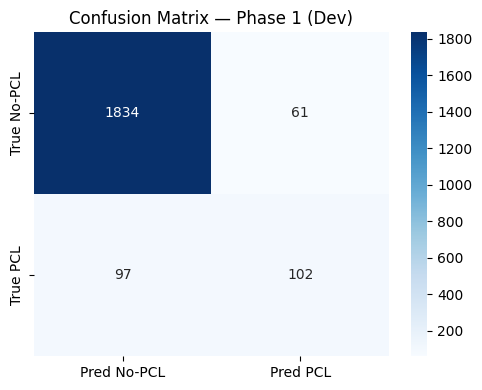

In [15]:
# ============================================================
# Phase 1 evaluation (best checkpoint)
# ============================================================
p1_eval = p1_trainer.evaluate()
print('Phase 1 dev metrics (best checkpoint):')
for k, v in p1_eval.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

p1_pred_out = p1_trainer.predict(p1_dev_ds)
y_true = p1_pred_out.label_ids
y_pred = np.argmax(p1_pred_out.predictions, axis=-1)

print('\n' + classification_report(y_true, y_pred, target_names=['No-PCL', 'PCL'], digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred No-PCL', 'Pred PCL'],
            yticklabels=['True No-PCL', 'True PCL'])
plt.title('Confusion Matrix — Phase 1 (Dev)')
plt.tight_layout()
plt.savefig(os.path.join(RUN_NAME_P1, 'confusion_matrix.png'), dpi=150)
plt.show()

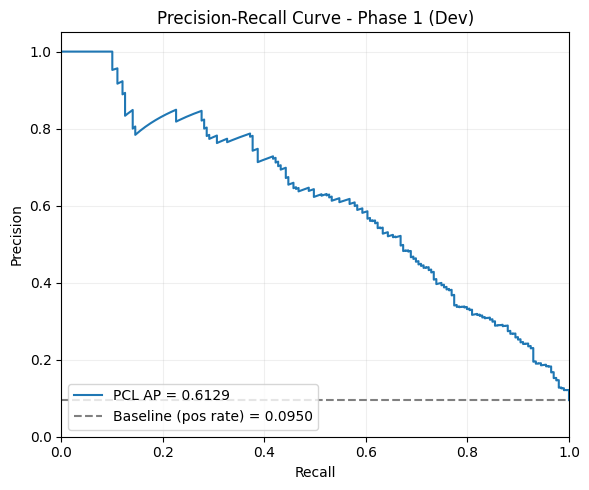

In [16]:
# ============================================================
# Precision-Recall curve (Phase 1 dev)
# ============================================================
from sklearn.metrics import precision_recall_curve, average_precision_score

logits = p1_pred_out.predictions
logits = logits - np.max(logits, axis=1, keepdims=True)  # stable softmax
exp_logits = np.exp(logits)
pcl_probs = exp_logits[:, 1] / np.sum(exp_logits, axis=1)

precision, recall, _ = precision_recall_curve(y_true, pcl_probs)
ap = average_precision_score(y_true, pcl_probs)
baseline = float(np.mean(y_true == 1))

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'PCL AP = {ap:.4f}')
plt.hlines(baseline, 0, 1, colors='gray', linestyles='--',
           label=f'Baseline (pos rate) = {baseline:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Phase 1 (Dev)')
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(alpha=0.2)
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig(os.path.join(RUN_NAME_P1, 'precision_recall_curve.png'), dpi=150)
plt.show()

In [17]:
error_df = dev_base_df.copy()
error_df['y_true'] = y_true
error_df['y_pred'] = y_pred
error_df['correct'] = (error_df['y_true'] == error_df['y_pred'])

# The four error categories
fn_df = error_df[(error_df['y_true'] == 1) & (error_df['y_pred'] == 0)]  # False Negatives — missed PCL
fp_df = error_df[(error_df['y_true'] == 0) & (error_df['y_pred'] == 1)]  # False Positives — wrongly flagged

In [18]:

with pd.option_context(
    'display.max_colwidth', None,
    'display.max_rows', 10
):
    print("=== FALSE NEGATIVES (PCL the model missed) ===")
    display(fn_df[['text', 'keyword', 'country']].head(10))
    
    print("\n=== FALSE POSITIVES (Not PCL but model flagged) ===")
    display(fp_df[['text', 'keyword', 'country']].head(10))

=== FALSE NEGATIVES (PCL the model missed) ===


,text,keyword,country
0,We also know that they can benefit by receiving counseling from someone who can help them understand that their feelings are normal and that their situation is not hopeless ; someone who can help them put their situation in perspective and help them communicate with others who could provide support ; someone knowledgeable about resources they can access ; someone who can help them plan for their needs and the needs of their child by developing either a parenting plan or an adoption plan .,hopeless,us
2,"Many refugees do n't want to be resettled anywhere , let alone in the US .",refugee,ng
4,"""In a 90-degree view of his constituency , one can see a high rise and a flyover while underneath it , homeless people sleep on pavements . """" As you can see , my constituency is not confined to one socio-economic group , """" he said , adding that apart from water , another major concern for him is to improve the standard of public schools in the area .""",homeless,pk
5,"He depicts demonstrations by refugees at the border post , their catastrophic living conditions and the desperate attempt of several hundred to cross a river a few kilometres from the camp to get into Macedonia on 14 March 2016 .",refugee,nz
8,t is remiss not to mention here that not all scavenging children come from poor families . Children hailing from affluent families use dumpsites as playgrounds .,poor-families,tz
9,""""""" People do n't understand the hurt , people do n't understand the pain . I 've read about women with their children sleeping in cars , sleeping in hotel rooms and it 's criminal . If they 're lucky and they come across COPE Galway and the ladies in Osterley , then there 's hope . """"""",women,ie
10,"Sheepherding in America has always been an immigrant 's job , too dirty , too cold and too lonely for anyone with options .",immigrant,us
12,"KARACHI - On the eve of International Women 's Day , Pakistan People 's Party Chairman Bilawal Bhutto Zardari has announced that his party 's Women Wing will organise Karwan-e-Benazir rallies in all the provincial capitals and in Azad Jammu &amp; Kashmir , Gilgit-Baltistan and Fata to celebrate the day and PPP 's achievements for empowerment of women in the country .",women,pk
13,If only we had more stories that championed the brilliance of migrant workers perhaps we 'd be able to challenge the silence that permits them to be treated in such a disdainful way .,migrant,ph
14,"Kasun may not be a superhero or a super genius but he is a great human being who has overcome challenges and hardships of life without even having the full functional capability of his body . His courage and dedication may one day take him to high places in life but above all , for those who are feeling useless and hopeless even though they have fully functional limbs , Kasun 's story is going to be a lesson .",hopeless,lk



=== FALSE POSITIVES (Not PCL but model flagged) ===


,text,keyword,country
281,The Jali family in Brown 's Farm was elated as the City of Cape Town donated wheelchairs to their disabled members .,disabled,za
366,"""On Oct. 1 , at the Working America blog , a community affiliate of the AFL-CIO , New Hampshire writer Susan Bruce attempted to make sense of the outrage : """" The lack of compassion is troubling but the level of anger is even more disconcerting . I suspect that the anger some people have for the homeless is fueled by their own fears that they are only a paycheck or two away from being homeless themselves . """"""",homeless,us
390,His friends at the Chevron want people to know he was n't just a faceless homeless person . He was their friend and their family .,homeless,us
407,"Dacawi practically pioneered the concept of civic or community journalism in the city by writing on the plight of indigent patients , other people in need and worthwhile causes that moved people to respond .",in-need,ph
418,Khushi said women 's participation in various sectors of the society should be increased and this will help change the attitude of the people towards them .,women,bd
421,""""""" Your personal leadership has been critical to addressing the plight of the Rohingya who fled to safety in your country . I thank you for all you have done to assist these men , women and children in need , """" he wrote in the message .""",in-need,bd
449,"""E-mail Address : * <h> A clinic called """" Hope """" helps a Syrian refugee boy cope with diabetes""",refugee,ke
480,"Allman Town resident Sonya Wilson ( second left ) , and one of her daughters ( fourth left ) hand out boxed lunches to a group of homeless people on King Street , downtown Kingston , on Thursday .",homeless,jm
614,""""""" I always consider this job as a gift , being a nurse is a reward and task given by God to help those who are in need . Seeing your patient recover from an illness , watching their families smile when you give them care , and hearing the first cry of a newborn are just some of the things that make my work special . It might be a heavy work but it can lighten your heart , """" she expressed .""",in-need,ph
645,"On the occasion , Major Fahad also distributed ration among the 40 poor families present at the medical camp . He said that army had been struggling to protect and serve the people of Swat and had stood by them in every troubled hour . People hoped that more such free medical camps would be arranged in the future .",poor-families,pk


In [19]:
keyword_analysis = error_df.groupby('keyword').apply(
    lambda g: pd.Series({
        'total': len(g),
        'fn': ((g.y_true==1) & (g.y_pred==0)).sum(),
        'fp': ((g.y_true==0) & (g.y_pred==1)).sum(),
        'f1': f1_score(g.y_true, g.y_pred, zero_division=0)
    })
).round(3)
print(keyword_analysis.sort_values('f1'))

               total    fn    fp     f1
keyword                                
women          233.0  12.0   2.0  0.222
immigrant      218.0   6.0   0.0  0.250
disabled       194.0   9.0   4.0  0.435
migrant        207.0   3.0   2.0  0.444
refugee        188.0   7.0   6.0  0.480
hopeless       217.0  13.0  10.0  0.531
poor-families  190.0  21.0   9.0  0.531
homeless       212.0  16.0   7.0  0.531
in-need        226.0   5.0  16.0  0.727
vulnerable     209.0   5.0   5.0  0.750


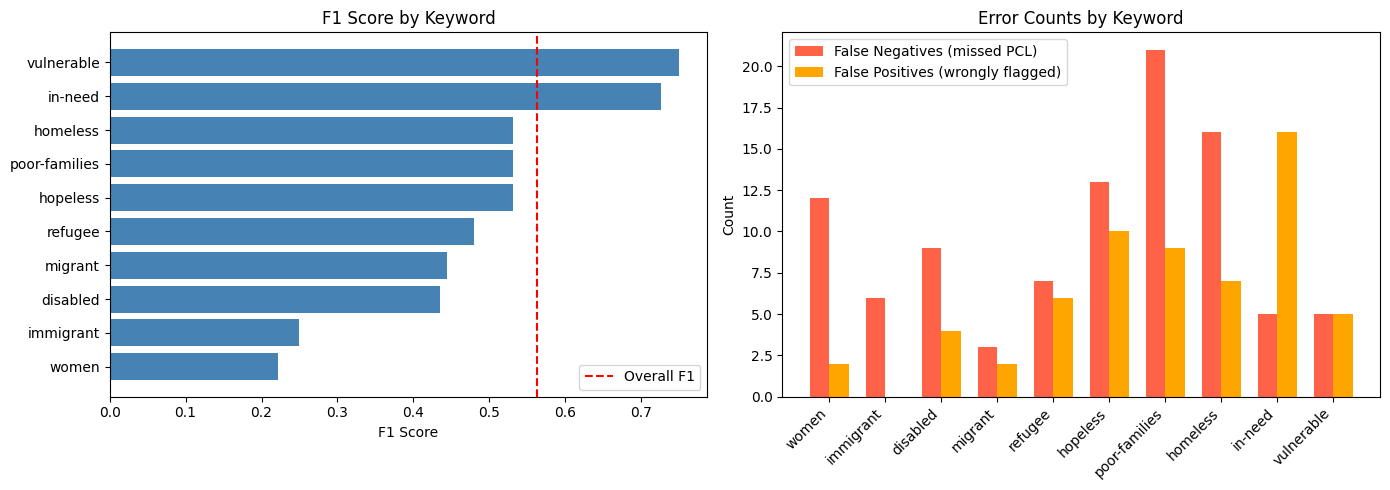

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 by keyword
keyword_analysis_sorted = keyword_analysis.sort_values('f1')
axes[0].barh(keyword_analysis_sorted.index, keyword_analysis_sorted['f1'], color='steelblue')
axes[0].axvline(x=f1_score(y_true, y_pred, zero_division=0), color='red', linestyle='--', label='Overall F1')
axes[0].set_xlabel('F1 Score')
axes[0].set_title('F1 Score by Keyword')
axes[0].legend()

# FN and FP counts by keyword
x = range(len(keyword_analysis_sorted))
width = 0.35
axes[1].bar([i - width/2 for i in x], keyword_analysis_sorted['fn'], width, label='False Negatives (missed PCL)', color='tomato')
axes[1].bar([i + width/2 for i in x], keyword_analysis_sorted['fp'], width, label='False Positives (wrongly flagged)', color='orange')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(keyword_analysis_sorted.index, rotation=45, ha='right')
axes[1].set_ylabel('Count')
axes[1].set_title('Error Counts by Keyword')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RUN_NAME_P1, "error_breakdown_by_keyword.png"), dpi=300)
plt.show()

# Generate dev and test results for Global Evaluation

In [21]:
# ============================================================
# Generate dev.txt  (official dev split order)
# ============================================================
# dev_base_df was ordered to match dev_ids_df, so p1_dev_ds rows align directly.
dev_preds = y_pred.tolist()

assert set(dev_preds).issubset({0, 1}), 'Unexpected values in dev predictions'
assert len(dev_preds) == len(dev_base_df), (
    f'Dev count mismatch: {len(dev_preds)} vs {len(dev_base_df)}'
)

with open(DEV_TXT_PATH, 'w') as f:
    f.write('\n'.join(str(p) for p in dev_preds) + '\n')

print(f'Written {len(dev_preds):,} predictions -> {DEV_TXT_PATH}')

Written 2,094 predictions -> dev.txt


---
## Phase 2 — Full retrain on all labelled data
Train + aug_train + dev + aug_dev combined; no held-out validation set.
A **fresh** `roberta-base` is used (same hyperparameters as Phase 1).

In [22]:
# ============================================================
# Phase 2 training set: train_base + aug_train + dev_base + aug_dev
# ============================================================
p2_train_df = pd.concat(
    [train_base_df, aug_train_df, dev_base_df, aug_dev_df],
    ignore_index=True,
).sample(frac=1, random_state=SEED).reset_index(drop=True)

p2_cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=p2_train_df['label'].values)

print(f'Phase 2 train: {len(p2_train_df):,} | PCL={int((p2_train_df.label==1).sum()):,} | No-PCL={int((p2_train_df.label==0).sum()):,}')
print(f'Class weights -> No-PCL: {p2_cw[0]:.4f},  PCL: {p2_cw[1]:.4f}')

p2_train_ds = build_dataset(p2_train_df)
print(p2_train_ds)

Phase 2 train: 17,022 | PCL=7,546 | No-PCL=9,476
Class weights -> No-PCL: 0.8982,  PCL: 1.1279


Map: 100%|██████████| 17022/17022 [00:00<00:00, 29559.89 examples/s]

Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 17022
})


Only used 3 epoch here instead of 5 because from the training above it seems that the model starts overfitting around epochs 2 and 3. But for the above it's fine because I am saving the best model anyways, not the final model.

In [23]:
# ============================================================
# Phase 2 model + trainer  (fresh roberta-base, no eval set)
# ============================================================
p2_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

p2_args = TrainingArguments(
    output_dir=RUN_NAME_P2,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=1e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type='cosine',
    optim='adamw_torch',
    eval_strategy='no',        # no validation set in Phase 2
    save_strategy='no',        # save only the final model below
    report_to='none',
    seed=SEED,
)

p2_trainer = WeightedCETrainer(
    model=p2_model,
    args=p2_args,
    train_dataset=p2_train_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    class_weights=p2_cw.tolist(),
)

print('Phase 2 trainer configured.')

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 537.63it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Phase 2 trainer configured.


In [24]:
p2_train_result = p2_trainer.train()
print(p2_train_result)

# Save final Phase 2 model
p2_final_dir = os.path.join(RUN_NAME_P2, 'final')
p2_trainer.save_model(p2_final_dir)
tokenizer.save_pretrained(p2_final_dir)
print(f'Phase 2 model saved to: {p2_final_dir}')

Step,Training Loss
500,0.441144
1000,0.249912
1500,0.151420
2000,0.099752
2500,0.045434
3000,0.032001


TrainOutput(global_step=3192, training_loss=0.16098785340636595, metrics={'train_runtime': 619.5333, 'train_samples_per_second': 82.427, 'train_steps_per_second': 5.152, 'total_flos': 3515434005107880.0, 'train_loss': 0.16098785340636595, 'epoch': 3.0})


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.40s/it]

Phase 2 model saved to: checkpoints/phase2/final


Error reported above is average training loss over all 3 epochs.

In [25]:
# ============================================================
# Generate test.txt  (3832 predictions in test file order)
# ============================================================
test_df = load_test_tsv(TEST_PATH)
test_df['clean_text'] = test_df['text'].apply(preprocess_text)
test_df['model_text'] = make_model_text(test_df)

test_ds       = build_dataset(test_df, has_labels=False)
test_pred_out = p2_trainer.predict(test_ds)
test_preds    = np.argmax(test_pred_out.predictions, axis=-1).tolist()

assert set(test_preds).issubset({0, 1}), 'Unexpected values in test predictions'
assert len(test_preds) == len(test_df), (
    f'Test count mismatch: {len(test_preds)} vs {len(test_df)}'
)

with open(TEST_TXT_PATH, 'w') as f:
    f.write('\n'.join(str(p) for p in test_preds) + '\n')

print(f'Written {len(test_preds):,} predictions -> {TEST_TXT_PATH}  (expected 3832)')

Map: 100%|██████████| 3832/3832 [00:00<00:00, 31400.76 examples/s]


Written 3,832 predictions -> test.txt  (expected 3832)


In [26]:
# ============================================================
# Sanity checks on output files
# ============================================================
for path in [DEV_TXT_PATH, TEST_TXT_PATH]:
    with open(path) as f:
        lines = [l.strip() for l in f if l.strip()]
    print(f'{path:12s}: lines={len(lines):,}, unique_labels={sorted(set(lines))}')

dev.txt     : lines=2,094, unique_labels=['0', '1']
test.txt    : lines=3,832, unique_labels=['0', '1']
